In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import re
from PIL.ImageColor import colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from pathlib import Path

project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "MFC2024"), None)
if project_root is None:
    raise FileNotFoundError("Could not locate project root folder named 'MFC2024'.")
print("Project root path:")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from configuration.initialize import *

Project root path:


In [ ]:
pola_tests_sim = {}
load_points = [10,20,30,35,40, 45, 50]

for RHC in [0.5, 0.0]:
    for P_des in [1.3,1.4,1.5]:
        for T_des in [323.15,333.15,343.15]:
            Ucell_test = []
            Rp_test = []
            states_test = []
            n = 0
            for I_LOAD in load_points:
                operating_inputs["Phi_c_des"] = RHC
                operating_inputs["Pa_des"] = P_des * 1e5
                operating_inputs["Pc_des"] = P_des * 1e5
                operating_inputs["T_des"] = T_des
                operating_inputs["current_density"] = lambda x: I_LOAD/parameters["Aact"]
                model = PEMFC_1D(parameters,operating_inputs, init_x(operating_inputs, parameters))
                sol = solve_ivp(model.dxdt, (0, 60), init_x(operating_inputs, parameters), method='BDF', max_step=1e-1)
                model._recovery(sol)
                states = {}
                for key, var_name in enumerate(model.variables):
                    states[var_name] = model.variables[var_name][-1]
                for key, var_name in enumerate(model.elec_variables):
                    states[var_name] = model.elec_variables[var_name][-1]
                states_test.append(states)
                n += 1
            states_profile = {}
            for key, value in enumerate(states_test[0].keys()):
                states_profile[value] = [states[value] for states in states_test]
            pola_tests_sim["RHC" + str(RHC) + "_P" + str(P_des) + "_T" + str(T_des)] = {"states":states_profile}

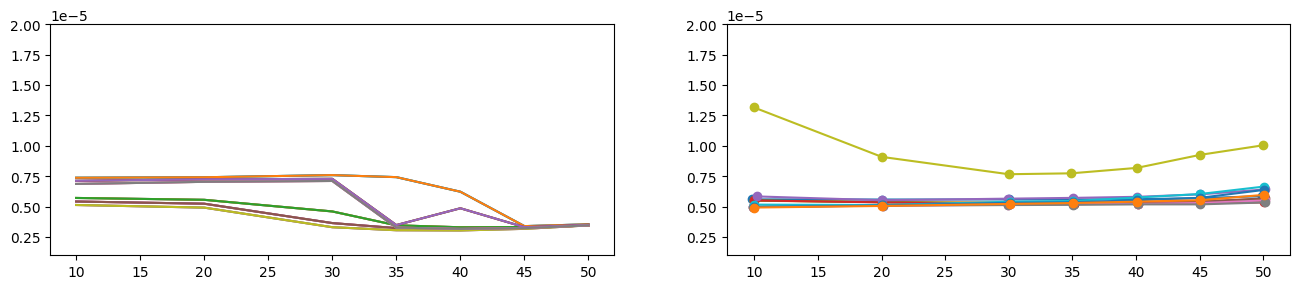

In [3]:
from ast import literal_eval

fig, ax = plt.subplots(figsize=(16, 3), nrows=1, ncols=2)
for key, value in pola_tests_sim.items():
    Rmem = [sum(Rmem_i) for Rmem_i in value["states"]["Rmem"]]
    ax[0].plot(load_points, np.array(Rmem), label=key)
ax[1].set_ylim(1e-6, 2e-5)
ax[0].set_ylim(ax[1].get_ylim())
exp_hfr_data = pd.ExcelFile("d:/PEMFC/MFC2024/data/HFR.xlsx")
hfr_testdata = {sname: pd.read_excel(exp_hfr_data, sheet_name=sname)
    for sname in exp_hfr_data.sheet_names}
for name, data in hfr_testdata.items():
    r_pairs = data["R"].map(literal_eval)
    r_pairs = np.array(r_pairs.tolist(), dtype=float)
    r_values = r_pairs[:, 0]      # resistance
    i_values = data["I_LOAD"].to_numpy(dtype=float)   # or r_pairs[:, 1]

    ax[1].plot(i_values, r_values * 30e-4 / (22 * 1e3), marker = 'o')

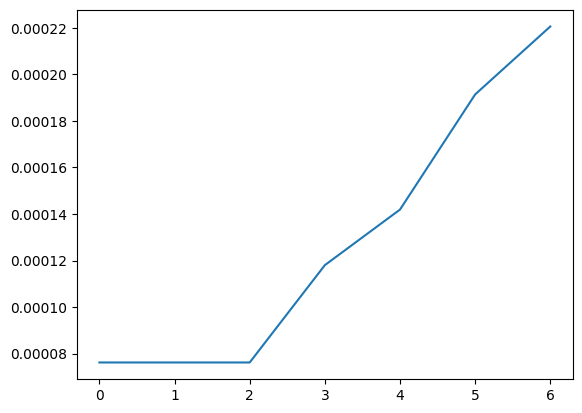

In [11]:
plt.plot(np.array(value["states"]["eta_conc"], dtype=float))

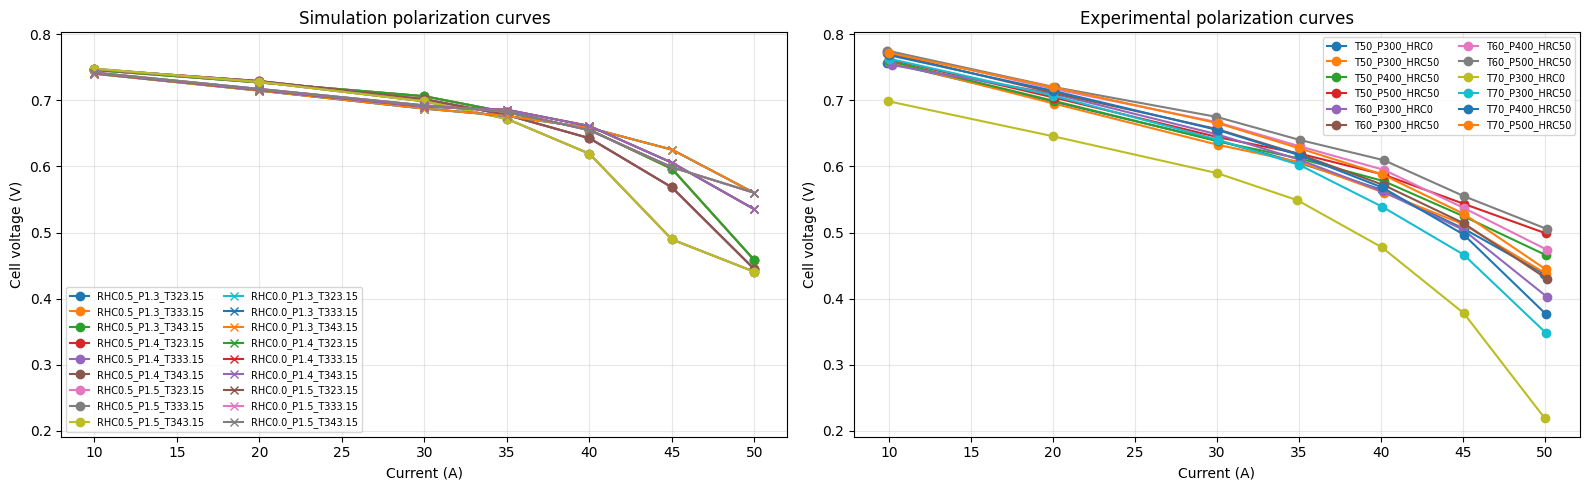

In [17]:
fig, ax = plt.subplots(figsize=(16, 5), nrows=1, ncols=2)
sim_voltage_curves = []
exp_voltage_curves = []

for key, value in pola_tests_sim.items():
    Ueq = np.array(value["states"]["Ueq"], dtype=float)
    i_fc = np.array(value["states"]["i_fc"], dtype=float)
    eta_act = np.array(value["states"]["eta_act"], dtype=float)
    eta_conc = np.array(value["states"]["eta_conc"], dtype=float)*1000
    Rmem = np.array([sum(Rmem_i) for Rmem_i in value["states"]["Rmem"]], dtype=float)
    Rccl = np.array(value["states"]["Rccl"], dtype=float)
    Rohm = Rmem + parameters["Re"]
    Ucell = 0.97 - i_fc * Rohm - eta_act - eta_conc
    sim_voltage_curves.append(Ucell)
    if "RHC0.5" in key:
        ax[0].plot(load_points, Ucell, marker='o', label=key)
    else:
        ax[0].plot(load_points, Ucell, marker='x', label=key)

exp_pola_data = pd.ExcelFile(project_root / "data" / "Polar_curves.xlsx")
pola_testdata = {sname: pd.read_excel(exp_pola_data, sheet_name=sname)
    for sname in exp_pola_data.sheet_names}

for name, data in pola_testdata.items():
    i_values = data["I_LOAD"].to_numpy(dtype=float)
    v_values = data["VFC"].to_numpy(dtype=float) / n_cell
    exp_voltage_curves.append(v_values)
    ax[1].plot(i_values, v_values, marker='o', label=name)


ax[0].set_title("Simulation polarization curves")
ax[0].set_xlabel("Current (A)")
ax[0].set_ylabel("Cell voltage (V)")
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=7, ncol=2)
ax[0].set_ylim(ax[1].get_ylim())

ax[1].set_title("Experimental polarization curves")
ax[1].set_xlabel("Current (A)")
ax[1].set_ylabel("Cell voltage (V)")
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

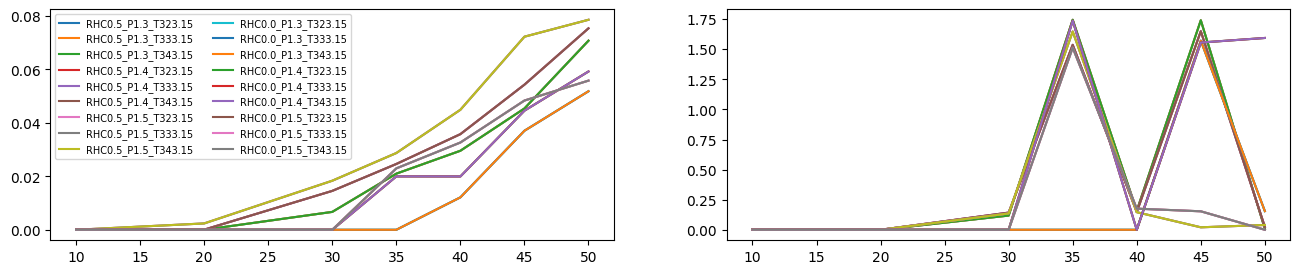

In [5]:
fig, ax = plt.subplots(figsize=(16, 3), nrows=1, ncols=2)
for key, value in pola_tests_sim.items():
    ax[0].plot(load_points, np.array(value["states"]["s_ccl"], dtype=float), label=key)
    ax[1].plot(load_points, np.array(value["states"]["s_cgdl_10"], dtype=float), label=key)
ax[0].legend(fontsize=7, ncol=2)